In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
df = pd.read_csv('epl_2025.csv')

df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,15/08/2025,20:00,Liverpool,Bournemouth,4,2,H,1,0,...,2.03,1.78,2.07,1.85,2.03,1.88,1.94,1.76,2.14,1.86
1,E0,16/08/2025,12:30,Aston Villa,Newcastle,0,0,D,0,0,...,2.05,1.80,2.02,1.89,2.06,1.80,1.95,1.74,2.14,1.86
2,E0,16/08/2025,15:00,Brighton,Fulham,1,1,D,0,0,...,1.83,2.03,1.93,2.00,1.84,2.03,1.80,1.96,1.91,2.08
3,E0,16/08/2025,15:00,Sunderland,West Ham,3,0,H,0,0,...,1.95,1.90,1.97,1.95,1.95,1.94,1.86,1.78,2.02,1.97
4,E0,16/08/2025,15:00,Tottenham,Burnley,3,0,H,1,0,...,1.98,1.88,1.99,1.93,1.98,1.91,1.88,1.83,2.07,1.92


In [3]:
df.shape


(291, 132)

In [4]:
df.columns

Index(['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTHG', 'HTAG',
       ...
       'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA',
       'AvgCAHH', 'AvgCAHA', 'BFECAHH', 'BFECAHA'],
      dtype='object', length=132)

In [5]:
df = df[[
    'Date',
    'HomeTeam',
    'AwayTeam',
    'FTHG',
    'FTAG',
    'FTR',
    'HS',
    'AS',
    'HST',
    'AST'
]]

In [6]:
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST
0,15/08/2025,Liverpool,Bournemouth,4,2,H,19,10,10,3
1,16/08/2025,Aston Villa,Newcastle,0,0,D,3,16,3,3
2,16/08/2025,Brighton,Fulham,1,1,D,10,7,4,2
3,16/08/2025,Sunderland,West Ham,3,0,H,10,12,5,4
4,16/08/2025,Tottenham,Burnley,3,0,H,16,14,6,4


In [7]:
df.shape

(291, 10)

In [8]:
df.columns

Index(['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS', 'AS',
       'HST', 'AST'],
      dtype='object')

In [9]:
df["Goal_Diff"] = df["FTHG"] - df["FTAG"]

In [10]:
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,Goal_Diff
0,15/08/2025,Liverpool,Bournemouth,4,2,H,19,10,10,3,2
1,16/08/2025,Aston Villa,Newcastle,0,0,D,3,16,3,3,0
2,16/08/2025,Brighton,Fulham,1,1,D,10,7,4,2,0
3,16/08/2025,Sunderland,West Ham,3,0,H,10,12,5,4,3
4,16/08/2025,Tottenham,Burnley,3,0,H,16,14,6,4,3


In [11]:
df['Result'] = df['FTR'].map({
    'H': 1,
    'D' : 0,
    'A' : -1,
})

In [12]:
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,Goal_Diff,Result
0,15/08/2025,Liverpool,Bournemouth,4,2,H,19,10,10,3,2,1
1,16/08/2025,Aston Villa,Newcastle,0,0,D,3,16,3,3,0,0
2,16/08/2025,Brighton,Fulham,1,1,D,10,7,4,2,0,0
3,16/08/2025,Sunderland,West Ham,3,0,H,10,12,5,4,3,1
4,16/08/2025,Tottenham,Burnley,3,0,H,16,14,6,4,3,1


In [13]:
df['FTR'].value_counts()

FTR
H    123
A     92
D     76
Name: count, dtype: int64

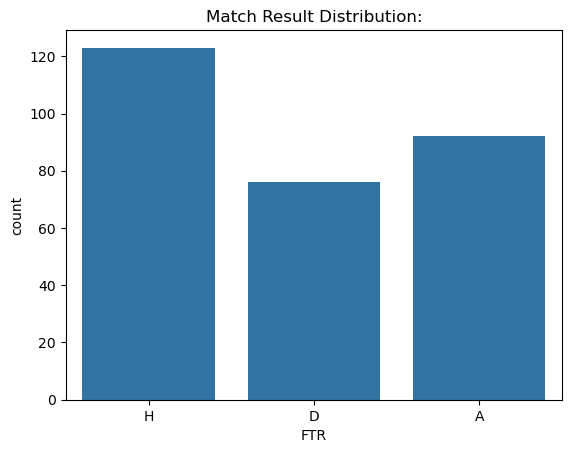

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='FTR', data = df)

plt.title('Match Result Distribution:')
plt.show()

In [15]:
print('Average home goals:' , df['FTHG'].mean())
print('Average away goals:' , df['FTAG'].mean())

Average home goals: 1.5154639175257731
Average away goals: 1.2577319587628866


In [16]:
df['FTR'].value_counts()

FTR
H    123
A     92
D     76
Name: count, dtype: int64

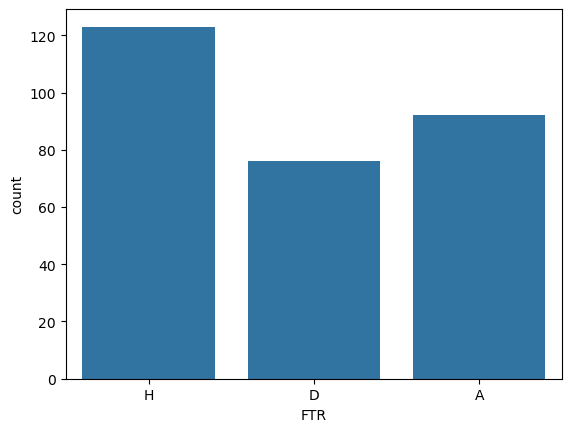

In [17]:
sns.countplot(x='FTR' , data = df)
plt.show()

In [18]:
home_goals = df.groupby("HomeTeam")["FTHG"].mean()
away_goals = df.groupby("AwayTeam")["FTAG"].mean()

df["Home_Attack_Strength"] = df["HomeTeam"].map(home_goals)
df["Away_Attack_Strength"] = df["AwayTeam"].map(away_goals)

In [19]:
df = df.fillna(0)

In [39]:
X = df[[
'HS',
'AS',
'HST',
'AST',
'Home_Attack_Strength',
'Away_Attack_Strength',
'Home_Form',
'Away_Form'
]]

In [40]:
y = df['Result']

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [43]:
y_pred = model.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.5254237288135594


In [45]:
df['Date'] = pd.to_datetime(df['Date'])

In [46]:
df = df.sort_values('Date')

In [47]:
df['Home_Points'] = df['FTR'].map({'H':3 , 'D':1 , 'A':0})
df['Away_Points'] = df['FTR'].map({'H':0 , 'D':1 ,'A':3})

In [48]:
df['Home_Form'] = df.groupby('HomeTeam')['Home_Points'].rolling(5).mean().reset_index(0,drop = True)
df['Away_Form'] = df.groupby('AwayTeam')['Away_Points'].rolling(5).mean().reset_index(0,drop = True)                             

In [49]:
df = df.fillna(0)

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators = 200 , random_state = 42)

rf_model.fit(X_train , y_train)
                                  

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
y_pred_rf = rf_model.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test , y_pred_rf)

print('Random Forest Accuracy :' , rf_accuracy)

Random Forest Accuracy : 0.5423728813559322


In [55]:
import pandas as pd 

importance = pd.Series(rf_model.feature_importances_, index = X.columns)

importance.sort_values(ascending=False)

HST                     0.136650
Away_Form               0.133484
Home_Attack_Strength    0.129895
HS                      0.129544
AST                     0.128458
Home_Form               0.125620
Away_Attack_Strength    0.114202
AS                      0.102147
dtype: float64

In [56]:
df['Predicted_Result'] = rf_model.predict(X)

In [57]:
df[['HomeTeam' , 'AwayTeam' , 'Result' , 'Predicted_Result']].head()

,HomeTeam,AwayTeam,Result,Predicted_Result
0,Liverpool,Bournemouth,1,1
1,Aston Villa,Newcastle,0,0
2,Brighton,Fulham,0,0
3,Sunderland,West Ham,1,1
4,Tottenham,Burnley,1,1


In [67]:
df['Home_Points_Pred'] = df['Predicted_Result'].map({1:3 , 0:1 , -1:0})
df['Away_Points_Pred'] = df['Predicted_Result'].map({1:0 , 0:1 , -1:3})

In [68]:
home_points = df.groupby('HomeTeam')['Home_Points_Pred'].sum()
away_points = df.groupby('AwayTeam')['Away_Points_Pred'].sum()

total_points = home_points.add(away_points, fill_value = 0)

In [69]:
league_table = total_points.sort_values(ascending = False)

league_table

HomeTeam
Man City          59
Aston Villa       55
Man United        55
Arsenal           54
Chelsea           48
Fulham            44
Crystal Palace    43
Newcastle         42
Sunderland        39
Leeds             38
Liverpool         37
Wolves            35
Brighton          34
Everton           34
Brentford         33
Bournemouth       32
Nott'm Forest     32
Tottenham         30
West Ham          29
Burnley           25
dtype: int64

In [71]:
print('Predicted EPL Winner:', league_table.index[0])

Predicted EPL Winner: Man City
